## <h3 align="center"> __Johns Hopkins University__</h3>
## <h3 align="center">__Whiting School of Engineering__</h3>
## <h3 align="center">__Engineering for Professionals__</h3>
## <h3 align="center">__685.801 Data Science: Independent Study__</h3>
## <h3 align="center">__Modeling Experiment__</h3>

---

- **Student:** `Dominick Dimpfel`  
- **Course:** `Data Science: Independent Study`  
- **Date:** `2026-06-05`  
- **Advisors:** `Ben Rodriguez, PhD`, `Amir Saeed`, `Ben Johnson`

---

## README (Execution & Setup)

- **Python version:** `3.12.13`
- **Platform:** `Linux`
- **Required packages:** `numpy`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`, `scipy`, `kagglehub`, `torch`, `torchvision` `statsmodels`
- **Install instructions (if non-standard):**
  ```bash
  # Uncomment and run cell 1 if cell 2 throws an error
  ```
- **Datasets used:**
  - `germam-traffic-sign-recognition-benchmark` downloaded (in notebook) from Kaggle: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/data
- **How to run this notebook:**

  0. It is highly recommended you use Google Colab, or have a powerful GPU setup, to run this notebook as it can take hours to run.
  1. Run all cells in order (Kernel → Restart & Run All).
  2. Ensure figures and tables render correctly.

---

In [ ]:
! pip install -q numpy pandas scipy seaborn matplotlib scikit-learn \
    kagglehub torch torchvision statsmodels torchao torchmetrics
! pip install -q --upgrade torch
! pip install -q --upgrade torchao
! pip install -q --upgrade torchvision

In [ ]:
# Environment Check
import sys, platform
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
try:
    import numpy as np, pandas as pd, scipy, seaborn, matplotlib, sklearn, statsmodels as sm, torch, torchvision, kagglehub
    print(f"numpy:      {np.__version__}")
    print(f"pandas:     {pd.__version__}")
    print(f"scipy:      {scipy.__version__}")
    print(f"statsmodels:{sm.__version__}")
    print(f"sklearn:    {sklearn.__version__}")
    print(f"seaborn:    {seaborn.__version__}")
    print(f"pytorch:    {torch.__version__}")
    print(f"torchvision:{torchvision.__version__}")
    print(f"matplotlib: {matplotlib.__version__}")
    print(f"kagglehub:  {kagglehub.__version__}")
except Exception as e:
    print("Optional packages missing or version check failed:", e)
    print("Use the command in the cell above to install necessary packages.")

Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
numpy:      2.0.2
pandas:     2.2.2
scipy:      1.16.3
statsmodels:0.14.6
sklearn:    1.6.1
seaborn:    0.13.2
pytorch:    2.12.1+cu130
torchvision:0.27.1+cu130
matplotlib: 3.10.0
kagglehub:  1.0.2


In [ ]:
import os
import random
from datetime import date
from PIL import Image
from itertools import product
from IPython.display import display

import numpy as np
import pandas as pd

import kagglehub
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.model_selection import train_test_split
from plots import plot_feature_vbars, visualize_images
from continual_learning import (
    build_complete_dataloader,
    create_task_dataloaders,
    CILComputerVisionModel,
    train_and_evaluate_cil_model,
    serialize_save_model_training
)
from gre_model_base import (
    GeneralistRouterExperts,
    cost_proxy,
    expected_calibration_error,
    expert_metrics,
    router_entropy,
)

## Config

### Google Colab

In [ ]:
# Mount Google Colab to Drive for results saving
from google.colab import drive
drive.mount('/content/drive')
USING_GOOGLE_COLAB = True
COLAB_DRIVE_DEST_DIR = '/content/drive/MyDrive/is26_models/'
os.makedirs(COLAB_DRIVE_DEST_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
# Pull the required supporting libraries
repo_url = "https://github.com/ddimpfel/JHU_IS_26.git"

!git clone {repo_url}

repo_name = repo_url.split("/")[-1].replace(".git", "")

os.chdir(repo_name)

# verifies directory and files are correct
!pwd
!ls

### Customizable Hyperparameters

In [ ]:
# Set experminent settings
SEED=7
NUM_WORKERS = 4 if USING_GOOGLE_COLAB else 0
PIN_MEMORY = True if USING_GOOGLE_COLAB else False
PERSIST_WORKERS = True if USING_GOOGLE_COLAB else False
TOTAL_CLASSES = 9 # 13
BS_RESAMPLES = 1000

# Set model settings
# CIL Baseline Models
IMG_SIZE = 224
BATCH_SIZE= 64 if USING_GOOGLE_COLAB else 8
EPOCHS = 8 if USING_GOOGLE_COLAB else 5
NUM_TASKS = 3 # 5
EXEMPLAR_RATIO = 0.065
TASK_1_LR = 0.001
USE_CLASS_MASKING = True

# CIL GRE Models
NUM_EXPERTS = 6
HIDDEN_ROUTER_SIZE = 128
HIDDEN_EXPERT_SIZE = 128
DROPOUT = 0.1
TOP_K = 2
LAMBDA_AUX = 0.05
# GRE Plug-in Experiment
PLUG_IN_ADD_EXPERTS = 2

# Transformer Expert
TFE_D_MODEL = 32
TFE_NHEAD = 4

# PEFT LoRA
LORA_RANK = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05

### Determinism and Hardware

In [ ]:
np_rng = np.random.default_rng(seed=SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED) # if using multiple GPUs
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
cuda_available = torch.cuda.is_available()
print(f"Is CUDA available? {cuda_available}")

if cuda_available:
    device_count = torch.cuda.device_count()
    print(f"Number of CUDA devices: {device_count}")

    current_device = torch.cuda.current_device()
    print(f"Current CUDA device index: {current_device}")

    device_name = torch.cuda.get_device_name(current_device)
    print(f"Current CUDA device name: {device_name}")

device = 'cuda' if cuda_available else 'cpu'
tor_gen = torch.Generator(device='cpu').manual_seed(SEED)

Is CUDA available? True
Number of CUDA devices: 1
Current CUDA device index: 0
Current CUDA device name: NVIDIA L4


## Notebook Content

### Data Loading

In [ ]:
# From HW1 Problem 1a code:
GTSRB_DATASET_NAME = "meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
csv_paths: dict[str, Path | None] = {
    "train.csv": None,
    "test.csv": None,
    "meta.csv": None
}

# --- Download latest from Kaggle ---
download_dir = Path(kagglehub.dataset_download(GTSRB_DATASET_NAME))

# 1) Exact match (case-insensitive)
for csv in download_dir.rglob("*.csv"):
    if csv.name.lower() in {n.lower() for n in csv_paths}:
        csv_paths[csv.name.lower()] = csv

print("Kaggle dataset directory:", str(download_dir))
for name, path in csv_paths.items():
    print(f"Resolved {name} path: {path}")

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Kaggle dataset directory: /kaggle/input/gtsrb-german-traffic-sign
Resolved train.csv path: /kaggle/input/gtsrb-german-traffic-sign/Train.csv
Resolved test.csv path: /kaggle/input/gtsrb-german-traffic-sign/Test.csv
Resolved meta.csv path: /kaggle/input/gtsrb-german-traffic-sign/Meta.csv


In [ ]:
! wget https://raw.githubusercontent.com/georgesung/traffic_sign_classification_german/master/signnames.csv -P .

--2026-06-28 22:31:09--  https://raw.githubusercontent.com/georgesung/traffic_sign_classification_german/master/signnames.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 999 [text/plain]
Saving to: ‘./signnames.csv’

signnames.csv       100%[===================>]     999  --.-KB/s    in 0s      

2026-06-28 22:31:09 (82.4 MB/s) - ‘./signnames.csv’ saved [999/999]



In [ ]:
train_csv = pd.read_csv(str(csv_paths['train.csv']))

train_df, val_df = train_test_split(
    train_csv,
    test_size=0.2,
    shuffle=True,
    stratify=train_csv.ClassId,
    random_state=SEED
)
test_df = pd.read_csv(str(csv_paths['test.csv']))

prohibitory_sign_classes = [i for i in range(1, 11)] # speed limits and no passing
# prohibitory_sign_classes += [15, 16, 17] # no vehicles, no trucks, no entry
prohibitory_sign_classes.remove(6) # remove de-restriction sign (end of 80 kph)

prohib_train_df = train_df[train_df.ClassId.isin(prohibitory_sign_classes)].reset_index()
prohib_val_df = val_df[val_df.ClassId.isin(prohibitory_sign_classes)].reset_index()
prohib_test_df = test_df[test_df.ClassId.isin(prohibitory_sign_classes)].reset_index()

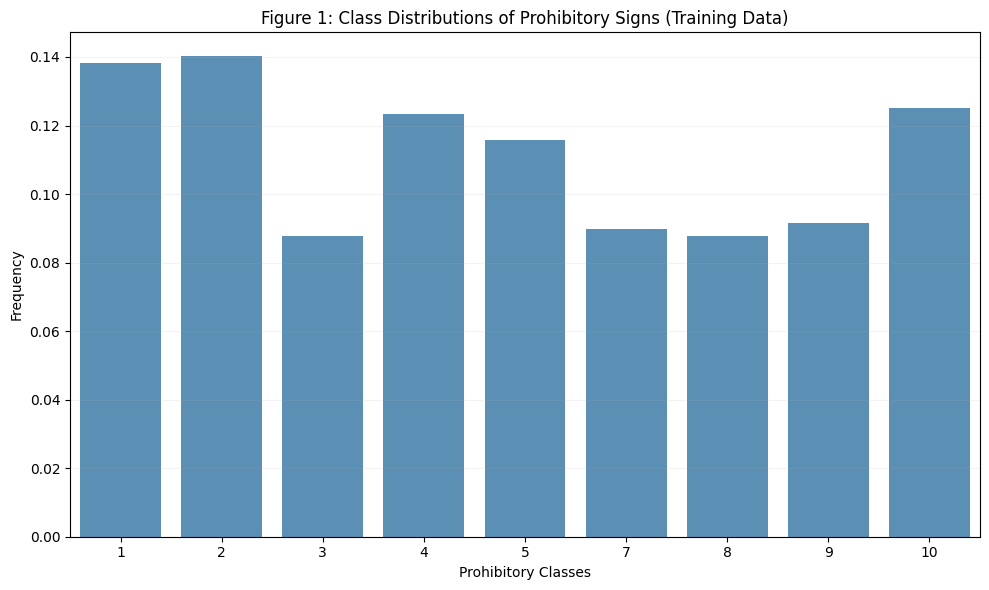

In [ ]:
plot_feature_vbars(prohib_train_df.ClassId, feature_name='Prohibitory Classes', title='Class Distributions of Prohibitory Signs (Training Data)')

In [ ]:
psc = prohibitory_sign_classes.copy()
np_rng.shuffle(psc)

rand_prohib_classes = [
    [psc[i], psc[i+1], psc[i+2]]
    for i in range(0, 9, 3)
]

In [ ]:
# Compute balanced weights matching the sorted order
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(prohibitory_sign_classes),
    y=prohib_train_df.ClassId.values
)
class_weights_dict = dict(zip(prohibitory_sign_classes, weights))
weights_tensor = torch.tensor(list(class_weights_dict.values()), dtype=torch.float, device=device)

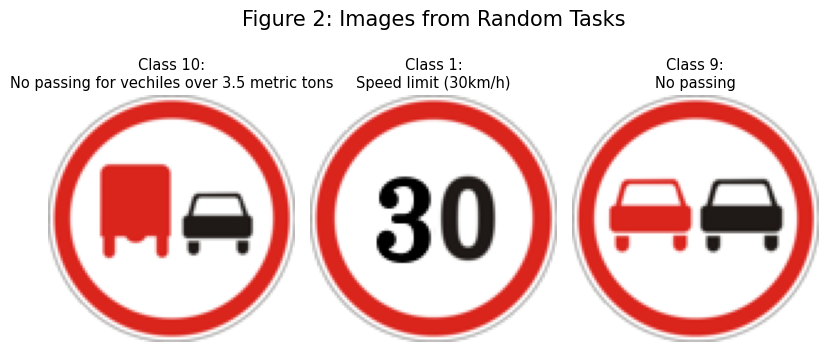

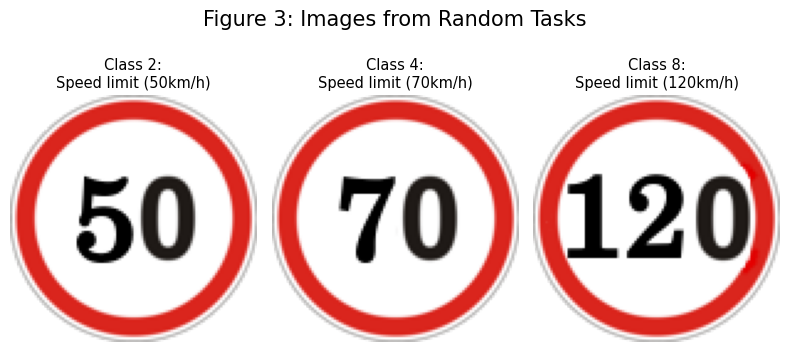

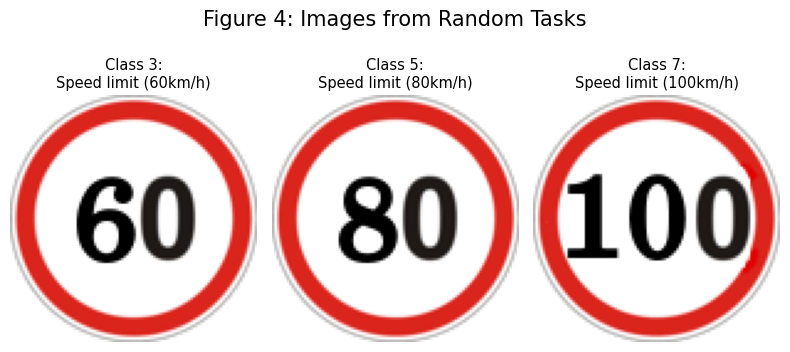

In [ ]:
class_names = pd.read_csv('./signnames.csv')
meta_df = pd.read_csv(csv_paths['meta.csv'])
prohibitory_class_names = class_names[class_names.ClassId.isin(prohibitory_sign_classes)].reset_index(drop=True)
for task_classes in rand_prohib_classes:
    visualize_images(meta_df, download_dir, task_classes, prohibitory_class_names, "Random Tasks", nrows=1, ncols=3, figsize=(8,4), fontsize_scaler=0.75)

### Data Setup/Transforming

In [ ]:
class TrafficSignDataset(Dataset):
    def __init__(self, data_dir, image_file_paths, targets, transformer, class_mapping):
        """
        Custom PyTorch dataset for getting GTSRB images and applying preprocessing transformations.
            Modified from Data Patterns and Representations HW3 (object detection with GTSDB).
        """
        if len(targets) != len(image_file_paths):
            raise AssertionError("Must have equal number of labels to images")

        self.data_dir = data_dir
        self.image_file_paths = list(image_file_paths)
        self.targets = list(targets)
        self.transformer = transformer
        self.class_mapping = class_mapping

    def __len__(self):
        return len(self.image_file_paths)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.image_file_paths[idx])

        image = Image.open(img_path).convert("RGB")
        transformed_img = self.transformer(image)
        label = self.class_mapping[self.targets[idx]]

        target = {
            'label': torch.tensor(label, dtype=torch.long)
        }

        return transformed_img, target, str(img_path)

def collate_data(return_values):
    images = [item[0] for item in return_values]
    targets = [item[1] for item in return_values]
    paths = [item[2] for item in return_values]
    return (images, targets, paths)

In [ ]:
transform_pipeline = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet standard values
])

In [ ]:
class_mapping = {raw_id: i for i, raw_id in enumerate(sorted(list(prohibitory_sign_classes)))}

train_dataset = TrafficSignDataset(
    download_dir,
    prohib_train_df.Path,
    prohib_train_df.ClassId,
    transform_pipeline,
    class_mapping
)

train_dataloaders = create_task_dataloaders(
    train_dataset,
    rand_prohib_classes,
    batch_size=BATCH_SIZE,
    collate_fn=collate_data
)

In [ ]:
class_mapping = {raw_id: i for i, raw_id in enumerate(sorted(list(prohibitory_sign_classes)))}

val_dataset = TrafficSignDataset(
    download_dir,
    prohib_val_df.Path,
    prohib_val_df.ClassId,
    transform_pipeline,
    class_mapping
)

val_dataloaders = create_task_dataloaders(
    val_dataset,
    rand_prohib_classes,
    batch_size=BATCH_SIZE,
    collate_fn=collate_data
)

In [ ]:
test_dataset = TrafficSignDataset(
    download_dir,
    prohib_test_df.Path,
    prohib_test_df.ClassId,
    transform_pipeline,
    class_mapping
)

# The held out test set is used after full training, so it can be one dataloader
test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=collate_data,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSIST_WORKERS,
    generator=tor_gen
)

### Modeling Setup

#### Previous Models

In [ ]:
class MobileNetGeneralist(nn.Module):
    def __init__(self, num_classes):
        super(MobileNetGeneralist, self).__init__()
        base_model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        self.backbone = base_model.features
        self.pool = base_model.avgpool

        self.out_channels = base_model.classifier[0].in_features
        self.classifier = nn.Sequential(
            nn.Linear(self.out_channels, num_classes),
            nn.LayerNorm(num_classes)
        )

    def forward(self, x, return_features=False):
        x = self.backbone(x)
        features = self.pool(x).flatten(1)
        logits = self.classifier(features)

        if return_features:
            return logits, features
        return logits

class MlpRouter(nn.Module):
    """Shallow gating network that produces per-expert routing logits."""
    def __init__(self, input_size, num_experts):
        super().__init__()
        self.num_experts = num_experts
        self.gating = nn.Linear(input_size, num_experts, bias=False)

    def forward(self, x):
        logits = self.gating(x)

        if self.training:
            noise = torch.randn_like(logits) * (1.0 / self.num_experts)
            logits = logits + noise

        return logits

class MlpExpert(nn.Module):
    """ Shallow neural network for classification prediction on general features. """
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super(MlpExpert, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            # nn.Linear(hidden_size, hidden_size),
            # nn.ReLU(inplace=True),
            # nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.network(x)

class TransformerExpert(nn.Module):
    def __init__(self, in_features, d_model, nhead, output_size):
        super(TransformerExpert, self).__init__()
        # The input features are already flattened so we slice
        #   the input into subvectors instead of patches
        if in_features % d_model != 0:
            raise ValueError("d_model must perfectly divide in_features")
        self.num_patches = in_features // d_model
        self.d_model = d_model

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches+1, d_model))

        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True),
            num_layers=1
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, output_size)
        )

    def forward(self, x):
        # From generalist, x.shape = (batch, flat_features)
        batch_size = x.shape[0]
        # slice x into "patches"
        x = x.view(batch_size, self.num_patches, self.d_model)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        # prepend transformer class tokens to patches and
        #   add positional embeddings of patches
        x = torch.cat((cls_tokens, x), dim=1) + self.pos_embed

        x = self.transformer(x)
        cls_output = x[:, 0, :]
        return self.classifier(cls_output)

#### Experimental Models

##### Generalists

In [ ]:
class ConvNeXtTinyGeneralist(nn.Module):
    def __init__(self, num_classes, weights=models.ConvNeXt_Tiny_Weights.DEFAULT, dropout=0.1):
        super().__init__()
        base_model = models.convnext_tiny(weights=weights)

        self.backbone = base_model.features
        self.pool = base_model.avgpool
        self.out_channels = base_model.classifier[2].in_features

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.out_channels),
            nn.Dropout(dropout),
            nn.Linear(self.out_channels, num_classes),
        )

    def forward(self, x, return_features=False):
        x = self.backbone(x)
        features = self.pool(x).flatten(1)
        logits = self.classifier(features)

        if return_features:
            return logits, features
        return logits

In [ ]:
class SwinTinyGeneralist(nn.Module):
    def __init__(self, num_classes, weights=models.Swin_T_Weights.DEFAULT, dropout=0.1):
        super().__init__()
        self.backbone = models.swin_t(weights=weights)
        self.out_channels = self.backbone.head.in_features

        # Use the pretrained Swin body as a feature extractor.
        self.backbone.head = nn.Identity()

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.out_channels),
            nn.Dropout(dropout),
            nn.Linear(self.out_channels, num_classes),
        )

    def forward(self, x, return_features=False):
        features = self.backbone(x)
        logits = self.classifier(features)

        if return_features:
            return logits, features
        return logits

##### Routers

In [ ]:
class LayeredRouter(nn.Module):
    """Deeper gating network that produces per-expert routing logits."""
    def __init__(self, input_size, num_experts):
        super().__init__()
        self.num_experts = num_experts
        self.ff1 = nn.Linear(input_size, input_size*2)
        self.ff2 = nn.Linear(input_size*2, num_experts, bias=False)

    def forward(self, x):
        logits = self.ff2(self.ff1(x))

        if self.training:
            noise = torch.randn_like(logits) * (1.0 / self.num_experts)
            logits = logits + noise

        return logits

##### Experts

In [ ]:
class ResidualGatedMlpExpert(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.LayerNorm(input_size),
            nn.Linear(input_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.block1 = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, hidden_size * 2),
            nn.GLU(dim=1),
            nn.Dropout(dropout),
        )

        self.block2 = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, hidden_size * 2),
            nn.GLU(dim=1),
            nn.Dropout(dropout),
        )

        self.classifier = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.input_proj(x)
        x = x + self.block1(x)
        x = x + self.block2(x)
        return self.classifier(x)

### Model Getters

#### Generalist Alterations

In [ ]:
def get_mobilenet_mlp_router_expert_gre(k=TOP_K):
    generalist = MobileNetGeneralist(num_classes=TOTAL_CLASSES)
    generalist_out_dim = generalist.out_channels

    router = MlpRouter(
        input_size=generalist_out_dim,
        num_experts=NUM_EXPERTS
    )

    def expert_factory():
        return MlpExpert(
            input_size=generalist_out_dim,
            hidden_size=HIDDEN_EXPERT_SIZE,
            output_size=TOTAL_CLASSES,
            dropout=DROPOUT
        )

    return GeneralistRouterExperts(
        generalist=generalist,
        router=router,
        expert_factory=expert_factory,
        num_experts=NUM_EXPERTS,
        num_classes=TOTAL_CLASSES,
        k=k,
        lambda_aux=LAMBDA_AUX
    )

In [ ]:
def get_convnext_mlp_router_expert_gre(k=TOP_K):
    generalist = ConvNeXtTinyGeneralist(num_classes=TOTAL_CLASSES)
    generalist_out_dim = generalist.out_channels

    router = MlpRouter(
        input_size=generalist_out_dim,
        num_experts=NUM_EXPERTS,
    )

    def expert_factory():
        return MlpExpert(
            input_size=generalist_out_dim,
            hidden_size=HIDDEN_EXPERT_SIZE,
            output_size=TOTAL_CLASSES,
            dropout=DROPOUT,
        )

    return GeneralistRouterExperts(
        generalist=generalist,
        router=router,
        expert_factory=expert_factory,
        num_experts=NUM_EXPERTS,
        num_classes=TOTAL_CLASSES,
        k=k,
        lambda_aux=LAMBDA_AUX,
    )

In [ ]:
def get_swintf_mlp_router_expert_gre(k=TOP_K):
    generalist = SwinTinyGeneralist(num_classes=TOTAL_CLASSES)
    generalist_out_dim = generalist.out_channels

    router = MlpRouter(
        input_size=generalist_out_dim,
        num_experts=NUM_EXPERTS,
    )

    def expert_factory():
        return MlpExpert(
            input_size=generalist_out_dim,
            hidden_size=HIDDEN_EXPERT_SIZE,
            output_size=TOTAL_CLASSES,
            dropout=DROPOUT,
        )

    return GeneralistRouterExperts(
        generalist=generalist,
        router=router,
        expert_factory=expert_factory,
        num_experts=NUM_EXPERTS,
        num_classes=TOTAL_CLASSES,
        k=k,
        lambda_aux=LAMBDA_AUX,
    )

#### Router Alterations

TBD what backbone to use

In [ ]:
def get_mobilenet_layered_router_mlp_expert_gre(k=TOP_K):
    generalist = MobileNetGeneralist(num_classes=TOTAL_CLASSES)
    generalist_out_dim = generalist.out_channels

    router = LayeredRouter(
        input_size=generalist_out_dim,
        num_experts=NUM_EXPERTS
    )

    def expert_factory():
        return MlpExpert(
            input_size=generalist_out_dim,
            hidden_size=HIDDEN_EXPERT_SIZE,
            output_size=TOTAL_CLASSES,
            dropout=DROPOUT,
        )

    return GeneralistRouterExperts(
        generalist=generalist,
        router=router,
        expert_factory=expert_factory,
        num_experts=NUM_EXPERTS,
        num_classes=TOTAL_CLASSES,
        k=k,
        lambda_aux=LAMBDA_AUX
    )

##### Expert Alterations

TBD what backbone and router to use

In [ ]:
def get_convnext_mlp_router_tf_expert_gre(k=TOP_K):
    generalist = ConvNeXtTinyGeneralist(num_classes=TOTAL_CLASSES)
    generalist_out_dim = generalist.out_channels

    router = MlpRouter(
        input_size=generalist_out_dim,
        num_experts=NUM_EXPERTS,
    )

    def expert_factory():
        return TransformerExpert(
            in_features=generalist_out_dim,
            d_model=TFE_D_MODEL,
            nhead=TFE_NHEAD,
            output_size=TOTAL_CLASSES
        )

    return GeneralistRouterExperts(
        generalist=generalist,
        router=router,
        expert_factory=expert_factory,
        num_experts=NUM_EXPERTS,
        num_classes=TOTAL_CLASSES,
        k=k,
        lambda_aux=LAMBDA_AUX,
    )

In [ ]:
def get_mobilenet_mlp_router_resmlp_expert_gre(k=TOP_K):
    generalist = MobileNetGeneralist(num_classes=TOTAL_CLASSES)
    generalist_out_dim = generalist.out_channels

    router = MlpRouter(
        input_size=generalist_out_dim,
        num_experts=NUM_EXPERTS
    )

    def expert_factory():
        return ResidualGatedMlpExpert(
            input_size=generalist_out_dim,
            hidden_size=HIDDEN_EXPERT_SIZE,
            output_size=TOTAL_CLASSES,
            dropout=DROPOUT
        )

    return GeneralistRouterExperts(
        generalist=generalist,
        router=router,
        expert_factory=expert_factory,
        num_experts=NUM_EXPERTS,
        num_classes=TOTAL_CLASSES,
        k=k,
        lambda_aux=LAMBDA_AUX
    )

### Model Training Pipeline

In [ ]:
GENERALIST_FACTORIES = {
    # "MobileNet": MobileNetGeneralist,
    # "ConvNeXt": ConvNeXtTinyGeneralist,
    "Swin-T": SwinTinyGeneralist,
}

ROUTER_FACTORIES = {
    # "MLP Router": MlpRouter,
    "Layered Router": LayeredRouter,
}

EXPERT_FACTORIES = {
    "MLP Experts": MlpExpert,
    "Transformer Experts": TransformerExpert,
    "ResMLP Experts": ResidualGatedMlpExpert,
}

def build_model_factory(generalist_name, router_name, expert_name, k=TOP_K):
    def model_factory():
        generalist = GENERALIST_FACTORIES[generalist_name](num_classes=TOTAL_CLASSES)
        generalist_out_dim = generalist.out_channels
        router = ROUTER_FACTORIES[router_name](
            input_size=generalist_out_dim,
            num_experts=NUM_EXPERTS,
        )

        def expert_factory():
            if expert_name == "MLP Experts":
                return MlpExpert(
                    input_size=generalist_out_dim,
                    hidden_size=HIDDEN_EXPERT_SIZE,
                    output_size=TOTAL_CLASSES,
                    dropout=DROPOUT,
                )
            if expert_name == "Transformer Experts":
                if generalist_out_dim % TFE_D_MODEL != 0:
                    raise ValueError(
                        f"TransformerExpert requires in_features divisible by d_model; ",
                        f"got in_features={generalist_out_dim}, d_model={TFE_D_MODEL}."
                    )
                return TransformerExpert(
                    in_features=generalist_out_dim,
                    d_model=TFE_D_MODEL,
                    nhead=TFE_NHEAD,
                    output_size=TOTAL_CLASSES,
                )
            if expert_name == "ResMLP Experts":
                return ResidualGatedMlpExpert(
                    input_size=generalist_out_dim,
                    hidden_size=HIDDEN_EXPERT_SIZE,
                    output_size=TOTAL_CLASSES,
                    dropout=DROPOUT,
                )
            raise KeyError(f"Unknown expert: {expert_name}")

        return GeneralistRouterExperts(
            generalist=generalist,
            router=router,
            expert_factory=expert_factory,
            num_experts=NUM_EXPERTS,
            num_classes=TOTAL_CLASSES,
            k=k,
            lambda_aux=LAMBDA_AUX,
        )

    return model_factory

def build_all_model_factories(k=TOP_K):
    model_factories = {}
    for generalist_name, router_name, expert_name in product(
        GENERALIST_FACTORIES.keys(),
        ROUTER_FACTORIES.keys(),
        EXPERT_FACTORIES.keys(),
    ):
        model_name = f"{generalist_name} + {router_name} + {expert_name}"
        model_factories[model_name] = build_model_factory(
            generalist_name=generalist_name,
            router_name=router_name,
            expert_name=expert_name,
            k=k,
        )
    return model_factories

### Model Comparison Runner

Train several continual-learning model variants with the same task split and compare their continual metrics, including backward transfer and full validation performance.

In [ ]:
def build_cil_model(model_factory, exemplar_ratio=EXEMPLAR_RATIO, use_class_masking=USE_CLASS_MASKING):
    return CILComputerVisionModel(
        model=model_factory(),
        exemplar_ratio=exemplar_ratio,
        rng=np_rng,
        device=device,
        use_class_masking=use_class_masking,
    )

def collect_gre_post_training_metrics(cil_model, eval_dataloader, num_classes=TOTAL_CLASSES, device=device):
    model = cil_model.model
    if not isinstance(model, GeneralistRouterExperts):
        return {}

    entropy_metrics = router_entropy(model, eval_dataloader, device=device)
    expert_summary = expert_metrics(model, eval_dataloader, device=device)
    ece = expected_calibration_error(
        model,
        num_classes=num_classes,
        val_data=eval_dataloader,
        device=device,
    )
    params = model.get_model_parameters_by_component()
    expected_calls = expert_summary["Expected Expert Calls"]

    return {
        "Post Training Router Entropy": entropy_metrics["Mean Router Entropy"],
        "Post Training Normalized Router Entropy": entropy_metrics["Normalized Router Entropy"],
        "Post Training Router Entropy Std": entropy_metrics["Std Router Entropy"],
        "Post Training Avg Router Prob": entropy_metrics["Avg Router Prob"],
        "Post Training ECE": ece,
        "Post Training Expected Expert Calls": expected_calls,
        "Post Training Expert Utilization Ratio": expert_summary["Expert Selection Ratio"],
        "Post Training Cost Proxy": cost_proxy(expected_calls, params),
    }

def run_model_comparisons(
    model_factories,
    train_dataloaders,
    val_dataloaders,
    optimizer_cls=AdamW,
    loss_fn=None,
    epochs=EPOCHS,
    num_tasks=NUM_TASKS,
    base_lr=TASK_1_LR,
    device=device,
    verbose=False,
 ):
    if loss_fn is None:
        loss_fn = CrossEntropyLoss(weight=weights_tensor)

    comparison_rows = []
    loss_histories = {}
    prediction_caches = {}
    trained_models = {}
    full_val_dataloader = build_complete_dataloader(val_dataloaders, shuffle=False)

    # Train and evaluate every model in the factory
    for model_name, model_factory in model_factories.items():
        print(f"\n=== Running {model_name} ===")
        cil_model = build_cil_model(model_factory)
        results, loss_history_per_task, pred_cache = train_and_evaluate_cil_model(
            cil_model=cil_model,
            optimizer_cls=optimizer_cls,
            loss_fn=loss_fn,
            train_dataloaders=train_dataloaders,
            val_dataloaders=val_dataloaders,
            epochs=epochs,
            num_tasks=num_tasks,
            base_lr=base_lr,
            device=device,
            verbose=verbose,
        )
        results.update(collect_gre_post_training_metrics(cil_model, full_val_dataloader, device=device))
        comparison_rows.append({"Model": model_name, **results})
        loss_histories[model_name] = loss_history_per_task
        prediction_caches[model_name] = pred_cache
        trained_models[model_name] = cil_model

        # Serialize results; save model and results
        model_out_path = f"{COLAB_DRIVE_DEST_DIR}{model_name}_{date.today()}"
        serialize_save_model_training(results, pred_cache, f"{model_out_path}.json")
        cil_model.save(filename=f"{model_out_path}.pth")

    comparison_df = pd.DataFrame(comparison_rows)
    return comparison_df, trained_models, loss_histories, prediction_caches

In [ ]:
model_factories = build_all_model_factories()

comparison_df, trained_models, loss_histories, prediction_caches = run_model_comparisons(
    model_factories=model_factories,
    train_dataloaders=train_dataloaders,
    val_dataloaders=val_dataloaders,
    optimizer_cls=AdamW,
    loss_fn=CrossEntropyLoss(weight=weights_tensor),
    epochs=EPOCHS,
    num_tasks=NUM_TASKS,
    base_lr=TASK_1_LR,
    device=device,
    verbose=False,
)


=== Running Swin-T + Layered Router + MLP Experts ===
Stage 3/3: Model GeneralistRouterExperts
Total compute time = 1282.28s

=== Running Swin-T + Layered Router + Transformer Experts ===
Stage 3/3: Model GeneralistRouterExperts
Total compute time = 1303.13s

=== Running Swin-T + Layered Router + ResMLP Experts ===
Stage 3/3: Model GeneralistRouterExperts
Total compute time = 1303.61s


,Model,AvgAcc,AvgAcc Macro F1,AvgAcc Micro F1,AvgAcc Weighted F1,Backward Transfer,Backward Transfer Macro F1,Backward Transfer Micro F1,Backward Transfer Weighted F1,Forward Transfer,Forward Transfer Macro F1,Forward Transfer Micro F1,Forward Transfer Weighted F1,Average Forgetting,Average Forgetting Macro F1,Average Forgetting Micro F1,Average Forgetting Weighted F1,Full Validation Loss,Full Validation Macro F1,Full Validation Micro F1,Full Validation Weighted F1,Baseline Accuracy,Total Compute Time (s)
0,Swin-T + Layered Router + ResMLP Experts,0.1301,0.1301,0.1312,0.1288,-0.4235,-0.4235,-0.4873,-0.4214,-0.0746,-0.0746,-0.1828,-0.2269,0.4235,0.4235,0.4873,0.4214,3.3919,0.0608,0.1156,0.0542,0.4292,1303.6
1,Swin-T + Layered Router + MLP Experts,0.1103,0.1103,0.1541,0.1518,-0.4520,-0.4520,-0.4757,-0.4369,-0.0284,-0.0284,-0.0507,-0.0795,0.4520,0.4520,0.4757,0.4369,3.3161,0.0783,0.1374,0.0737,0.4667,1282.3
2,Swin-T + Layered Router + Transformer Experts,0.1035,0.1035,0.1345,0.1069,-0.4955,-0.4955,-0.5277,-0.5056,-0.0602,-0.0602,-0.1821,-0.1829,0.4955,0.4955,0.5277,0.5056,3.2053,0.0437,0.1184,0.0395,0.5200,1303.1


,Model,Task Pair,Backward Transfer,Forward Transfer
0,Swin-T + Layered Router + MLP Experts,Task 1 → 2,-0.4667,-0.0224
1,Swin-T + Layered Router + MLP Experts,Task 2 → 3,-0.4373,-0.0343
2,Swin-T + Layered Router + Transformer Experts,Task 1 → 2,-0.5200,-0.0143
3,Swin-T + Layered Router + Transformer Experts,Task 2 → 3,-0.4710,-0.1060
4,Swin-T + Layered Router + ResMLP Experts,Task 1 → 2,-0.4292,-0.0599
5,Swin-T + Layered Router + ResMLP Experts,Task 2 → 3,-0.4178,-0.0893


,Model,AvgAcc Macro F1,AvgAcc Micro F1,AvgAcc Weighted F1,Average Forgetting Macro F1,Average Forgetting Micro F1,Average Forgetting Weighted F1,Backward Transfer Macro F1,Backward Transfer Micro F1,Backward Transfer Weighted F1,Forward Transfer Macro F1,Forward Transfer Micro F1,Forward Transfer Weighted F1
0,Swin-T + Layered Router + MLP Experts,0.1103,0.1541,0.1518,0.4520,0.4757,0.4369,-0.452002,-0.475733,-0.436869,-0.028356,-0.050727,-0.079529
1,Swin-T + Layered Router + Transformer Experts,0.1035,0.1345,0.1069,0.4955,0.5277,0.5056,-0.495523,-0.527734,-0.505564,-0.060168,-0.182082,-0.182887
2,Swin-T + Layered Router + ResMLP Experts,0.1301,0.1312,0.1288,0.4235,0.4873,0.4214,-0.423524,-0.487318,-0.421360,-0.074608,-0.182830,-0.226922


,Model,AvgAcc Macro F1,AvgAcc Micro F1,AvgAcc Weighted F1,Average Forgetting Macro F1,Average Forgetting Micro F1,Average Forgetting Weighted F1,Backward Transfer Macro F1,Backward Transfer Micro F1,Backward Transfer Weighted F1,Forward Transfer Macro F1,Forward Transfer Micro F1,Forward Transfer Weighted F1
0,Swin-T + Layered Router + MLP Experts,0.110347,0.154067,0.151806,0.452002,0.475733,0.436869,-0.4520,-0.4757,-0.4369,-0.0284,-0.0507,-0.0795
1,Swin-T + Layered Router + Transformer Experts,0.103494,0.134466,0.106930,0.495523,0.527734,0.505564,-0.4955,-0.5277,-0.5056,-0.0602,-0.1821,-0.1829
2,Swin-T + Layered Router + ResMLP Experts,0.130089,0.131223,0.128850,0.423524,0.487318,0.421360,-0.4235,-0.4873,-0.4214,-0.0746,-0.1828,-0.2269


/tmp/ipykernel_4742/678624651.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x=metric, y="Model", ax=ax, palette="viridis")
/tmp/ipykernel_4742/678624651.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x=metric, y="Model", ax=ax, palette="viridis")
/tmp/ipykernel_4742/678624651.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x=metric, y="Model", ax=ax, palette="viridis")
/tmp/ipykernel_4742/678624651.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

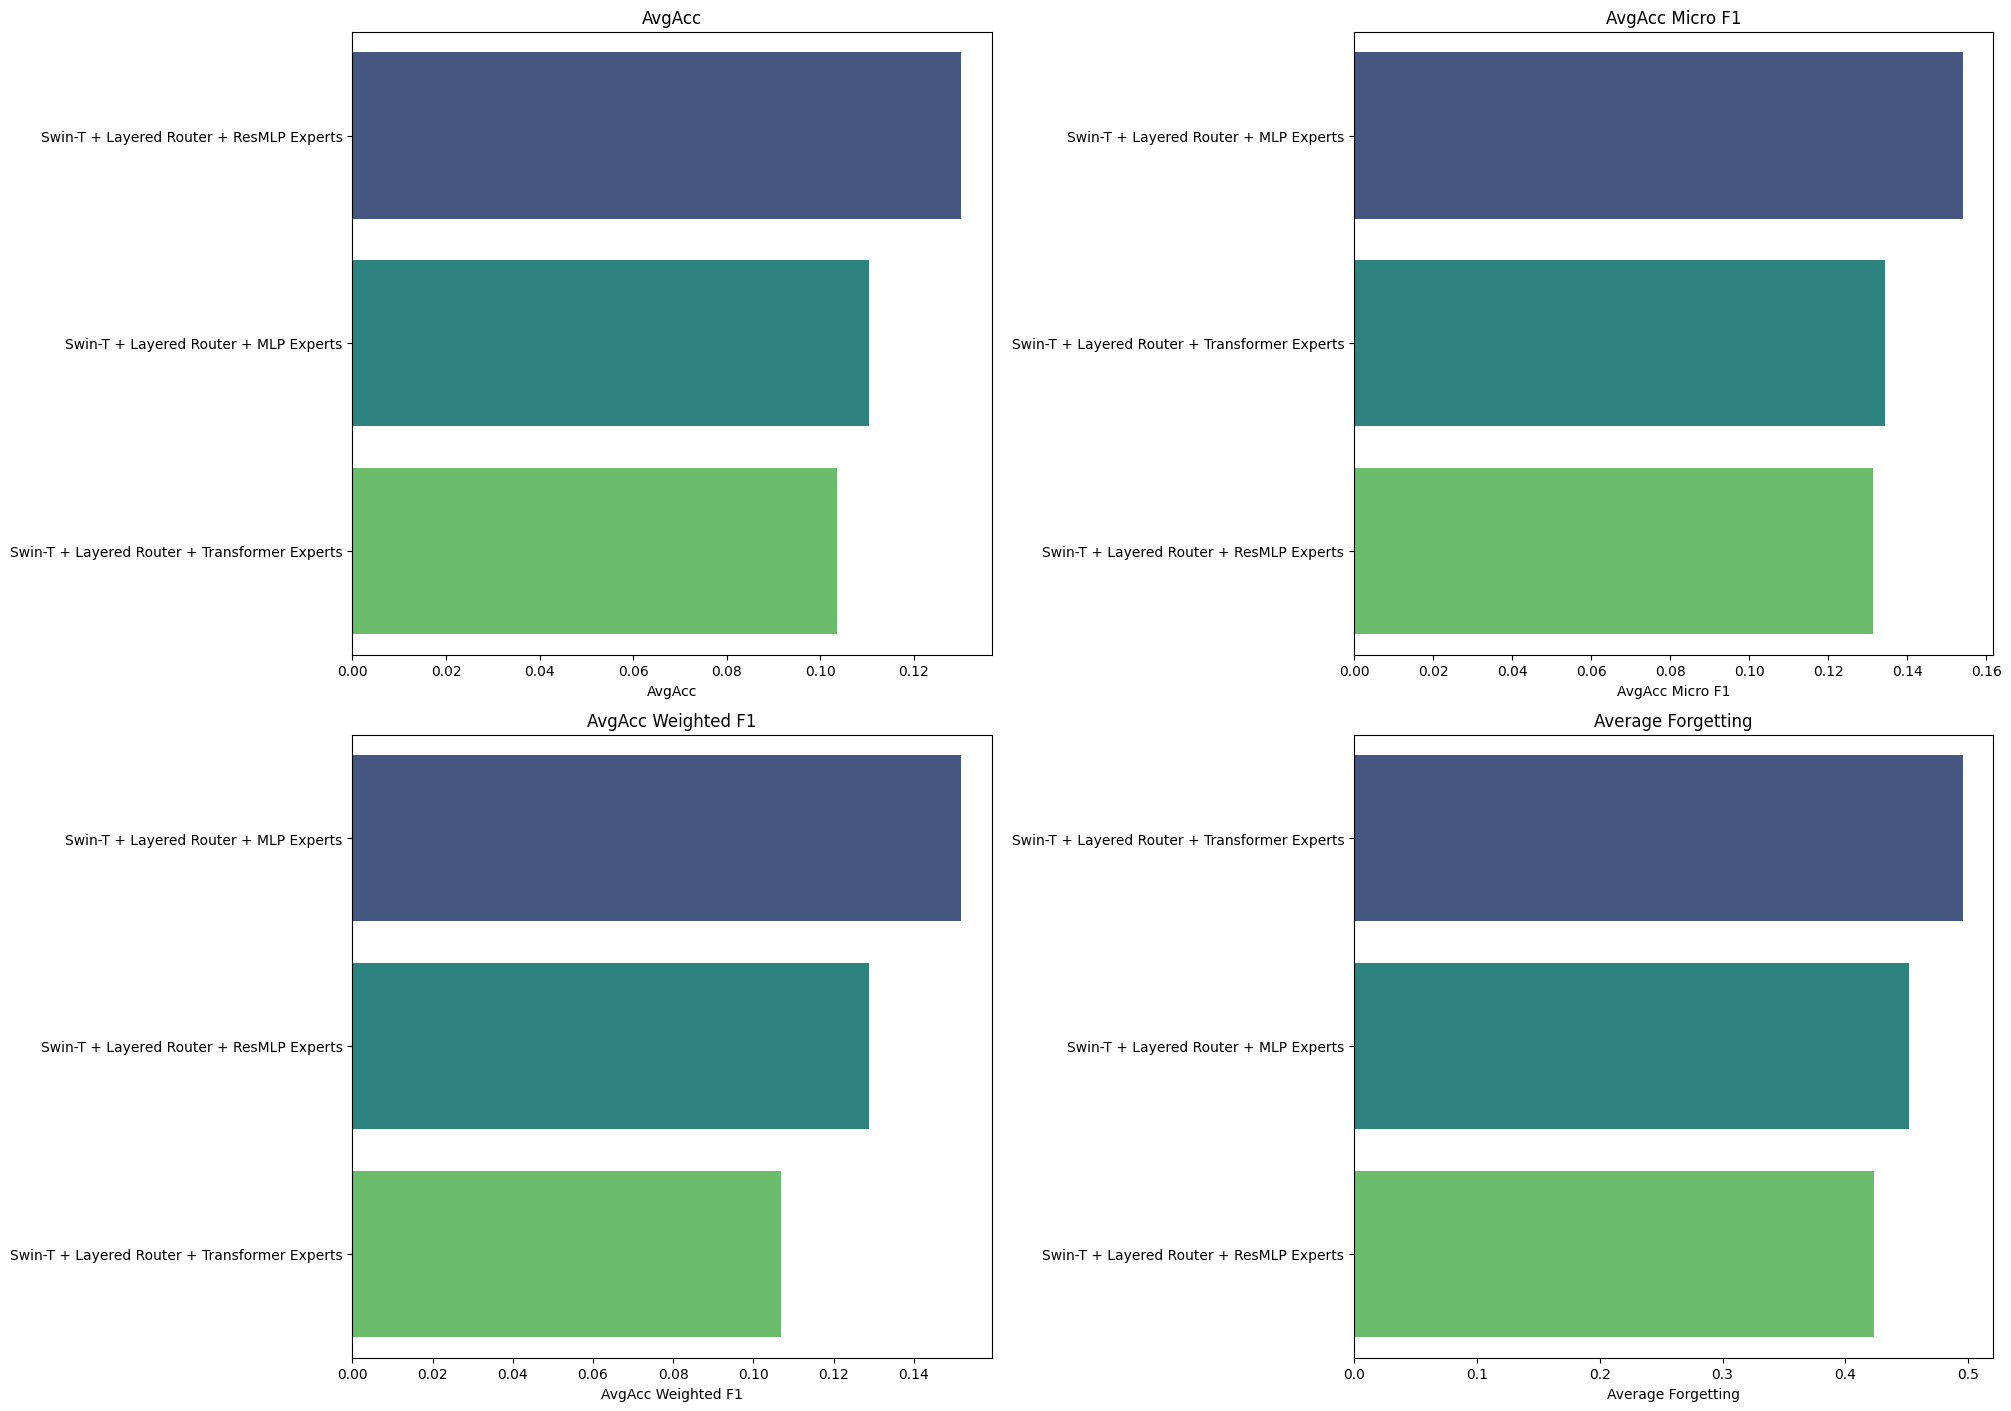

,Model,AvgAcc,AvgAcc Macro F1,AvgAcc Micro F1,AvgAcc Weighted F1,Backward Transfer,Backward Transfer Macro F1,Backward Transfer Micro F1,Backward Transfer Weighted F1,Forward Transfer,...,Average Forgetting,Average Forgetting Macro F1,Average Forgetting Micro F1,Average Forgetting Weighted F1,Full Validation Loss,Full Validation Macro F1,Full Validation Micro F1,Full Validation Weighted F1,Baseline Accuracy,Total Compute Time (s)
0,Swin-T + Layered Router + ResMLP Experts,0.130089,0.130089,0.131223,0.128850,-0.423524,-0.423524,-0.487318,-0.421360,-0.074608,...,0.423524,0.423524,0.487318,0.421360,3.391879,0.060793,0.115576,0.054197,0.429208,1303.613885
1,Swin-T + Layered Router + MLP Experts,0.110347,0.110347,0.154067,0.151806,-0.452002,-0.452002,-0.475733,-0.436869,-0.028356,...,0.452002,0.452002,0.475733,0.436869,3.316145,0.078329,0.137383,0.073729,0.466668,1282.283779
2,Swin-T + Layered Router + Transformer Experts,0.103494,0.103494,0.134466,0.106930,-0.495523,-0.495523,-0.527734,-0.505564,-0.060168,...,0.495523,0.495523,0.527734,0.505564,3.205268,0.043662,0.118380,0.039544,0.520017,1303.125432


In [ ]:
metric_columns = [
    "Model",
    "AvgAcc",
    "AvgAcc Macro F1",
    "AvgAcc Micro F1",
    "AvgAcc Weighted F1",
    "Backward Transfer",
    "Backward Transfer Macro F1",
    "Backward Transfer Micro F1",
    "Backward Transfer Weighted F1",
    "Forward Transfer",
    "Forward Transfer Macro F1",
    "Forward Transfer Micro F1",
    "Forward Transfer Weighted F1",
    "Average Forgetting",
    "Average Forgetting Macro F1",
    "Average Forgetting Micro F1",
    "Average Forgetting Weighted F1",
    "Full Validation Loss",
    "Full Validation Macro F1",
    "Full Validation Micro F1",
    "Full Validation Weighted F1",
    "Baseline Accuracy",
    "Total Compute Time (s)",
 ]



available_metric_columns = [column for column in metric_columns if column in comparison_df.columns]
summary_df = comparison_df.loc[:, available_metric_columns].copy()
summary_df = summary_df.sort_values(
    by=["AvgAcc", "Full Validation Macro F1"],
    ascending=False,
).reset_index(drop=True)

display(summary_df.style.format({
    "AvgAcc": "{:.4f}",
    "AvgAcc Macro F1": "{:.4f}",
    "AvgAcc Micro F1": "{:.4f}",
    "AvgAcc Weighted F1": "{:.4f}",
    "Backward Transfer": "{:.4f}",
    "Backward Transfer Macro F1": "{:.4f}",
    "Backward Transfer Micro F1": "{:.4f}",
    "Backward Transfer Weighted F1": "{:.4f}",
    "Forward Transfer": "{:.4f}",
    "Forward Transfer Macro F1": "{:.4f}",
    "Forward Transfer Micro F1": "{:.4f}",
    "Forward Transfer Weighted F1": "{:.4f}",
    "Average Forgetting": "{:.4f}",
    "Average Forgetting Macro F1": "{:.4f}",
    "Average Forgetting Micro F1": "{:.4f}",
    "Average Forgetting Weighted F1": "{:.4f}",
    "Full Validation Loss": "{:.4f}",
    "Full Validation Macro F1": "{:.4f}",
    "Full Validation Micro F1": "{:.4f}",
    "Full Validation Weighted F1": "{:.4f}",
    "Baseline Accuracy": "{:.4f}",
    "Total Compute Time (s)": "{:.1f}",
}))

transfer_rows = []
for _, row in comparison_df.iterrows():
    bwt_values = np.atleast_1d(np.asarray(row["Backward Transfer Per Task"], dtype=float))
    fwt_values = np.atleast_1d(np.asarray(row["Forward Transfer Per Task"], dtype=float))
    for task_index in range(min(len(bwt_values), len(fwt_values))):
        transfer_rows.append({
            "Model": row["Model"],
            "Task Pair": f"Task {task_index + 1} → {task_index + 2}",
            "Backward Transfer": bwt_values[task_index],
            "Forward Transfer": fwt_values[task_index],
        })

transfer_df = pd.DataFrame(transfer_rows)
display(transfer_df.style.format({
    "Backward Transfer": "{:.4f}",
    "Forward Transfer": "{:.4f}",
}))

f1_variant_columns = [
    "Model",
    "AvgAcc Macro F1",
    "AvgAcc Micro F1",
    "AvgAcc Weighted F1",
    "Average Forgetting Macro F1",
    "Average Forgetting Micro F1",
    "Average Forgetting Weighted F1",
    "Backward Transfer Macro F1",
    "Backward Transfer Micro F1",
    "Backward Transfer Weighted F1",
    "Forward Transfer Macro F1",
    "Forward Transfer Micro F1",
    "Forward Transfer Weighted F1",
]

available_f1_variant_columns = [column for column in f1_variant_columns if column in comparison_df.columns]
if len(available_f1_variant_columns) > 1:
    f1_variant_df = comparison_df.loc[:, available_f1_variant_columns].copy()
    display(f1_variant_df.style.format({
        "AvgAcc Macro F1": "{:.4f}",
        "AvgAcc Micro F1": "{:.4f}",
        "AvgAcc Weighted F1": "{:.4f}",
        "Average Forgetting Macro F1": "{:.4f}",
        "Average Forgetting Micro F1": "{:.4f}",
        "Average Forgetting Weighted F1": "{:.4f}",
    }))

    display(f1_variant_df.style.format({
        "Backward Transfer Macro F1": "{:.4f}",
        "Backward Transfer Micro F1": "{:.4f}",
        "Backward Transfer Weighted F1": "{:.4f}",
        "Forward Transfer Macro F1": "{:.4f}",
        "Forward Transfer Micro F1": "{:.4f}",
        "Forward Transfer Weighted F1": "{:.4f}",
    }))

fig, axes = plt.subplots(2, 2, figsize=(20, 14), constrained_layout=True)
plot_metrics = [
    "AvgAcc",
    "AvgAcc Micro F1",
    "AvgAcc Weighted F1",
    "Average Forgetting",
]

for ax, metric in zip(axes.flat, plot_metrics):
    plot_df = summary_df.sort_values(metric, ascending=False)
    sns.barplot(data=plot_df, x=metric, y="Model", ax=ax, palette="viridis")
    ax.set_title(metric)
    ax.set_xlabel(metric)
    ax.set_ylabel("")

plt.show()

summary_df

In [ ]:
gre_metric_columns = [
    "Model",
    "Post Training Router Entropy",
    "Post Training Normalized Router Entropy",
    "Post Training Router Entropy Std",
    "Post Training ECE",
    "Post Training Expected Expert Calls",
    "Post Training Cost Proxy",
    "Post Training Expert Utilization Ratio",
]

available_gre_columns = [column for column in gre_metric_columns if column in comparison_df.columns]
if len(available_gre_columns) > 1:
    gre_metrics_df = comparison_df.loc[:, available_gre_columns].copy()
    display(gre_metrics_df.style.format({
        "Post Training Router Entropy": "{:.4f}",
        "Post Training Normalized Router Entropy": "{:.4f}",
        "Post Training Router Entropy Std": "{:.4f}",
        "Post Training ECE": "{:.4f}",
        "Post Training Expected Expert Calls": "{:.4f}",
        "Post Training Cost Proxy": "{:.0f}",
    }))
else:
    print("No GRE-specific post-training metrics were captured.")

,Model,Post Training Router Entropy,Post Training Normalized Router Entropy,Post Training Router Entropy Std,Post Training ECE,Post Training Expected Expert Calls,Post Training Cost Proxy,Post Training Expert Utilization Ratio
0,Swin-T + Layered Router + MLP Experts,0.0269,0.0150,0.1088,0.2806,2.0000,28917397,[0.4923676 0. 0. 0.16713396 0. 0.34049845]
1,Swin-T + Layered Router + Transformer Experts,0.0000,0.0000,0.0000,0.2483,2.0000,28995605,[0. 0.5 0.5 0. 0. 0. ]
2,Swin-T + Layered Router + ResMLP Experts,0.0006,0.0003,0.0171,0.2701,2.0000,29053589,[0. 0.00498442 0.09859813 0. 0.5 0.39641744]
